# XGBoost Baseline — Predicción de Sepsis

Modelo de referencia con features clínicas validadas: SOFA, qSOFA, SIRS y valores de lab/vitales.

**Horizontes**: 6h y 12h antes del onset de sepsis.  
**Métricas**: AUROC, AUPRC, sensibilidad a especificidad fija 90%.  
**Interpretabilidad**: SHAP values.

### Definición del tiempo de referencia

| Grupo | Horizonte 6h | Horizonte 12h |
|---|---|---|
| Sepsis | `onset_hour − 6` | `onset_hour − 12` |
| No-sepsis | hora aleatoria en `[24, los_hours − 6]` | hora aleatoria en `[24, los_hours − 12]` |

In [1]:
import polars as pl
import numpy as np
import json
from pathlib import Path
import time

import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
import shap
import matplotlib.pyplot as plt

MIMIC   = Path.home() / "mimic-iv-3.0"
HOSP    = MIMIC / "hosp"
PROC    = Path("../data/processed")
OUT_DIR = Path("../experiments/xgboost")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

def log(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}")

print(f"XGBoost {xgb.__version__}")

XGBoost 2.1.4


## PASO 1 — Cargar datos base

In [2]:
log("Cargando cohort, splits, vitales y labs ...")

# onset_hour no está en cohort.parquet (tiene onset_time datetime);
# lo calculamos desde vitals_hourly que ya lo tiene como Int32
cohort = pl.read_parquet(PROC / "cohort.parquet").select([
    "subject_id", "stay_id", "los_hours",
    "sepsis", "onset_time",
    "sofa", "sofa_coag", "sofa_liver", "sofa_renal",
    "sofa_cns", "sofa_cardio", "sofa_resp",
])

splits = pl.read_parquet(PROC / "splits.parquet").select(["stay_id", "split"])
cohort = cohort.join(splits, on="stay_id", how="left")

# onset_hour = hours_from_intime del onset (pre-calculado en 03_extract_vitals)
vitals_meta = (
    pl.read_parquet(PROC / "vitals/vitals_hourly.parquet",
                    columns=["stay_id", "onset_hour"])
    .unique(subset=["stay_id"])
)
cohort = cohort.join(vitals_meta, on="stay_id", how="left")

patients = pl.read_csv(
    HOSP / "patients.csv.gz",
    columns=["subject_id", "gender", "anchor_age"]
).with_columns(
    (pl.col("gender") == "M").cast(pl.Int8).alias("male")
)
cohort = cohort.join(
    patients.select(["subject_id", "anchor_age", "male"]),
    on="subject_id", how="left"
)

log(f"Cohorte: {len(cohort):,} stays")
print(f"Columnas: {cohort.columns}")

VITAL_COLS = ["heart_rate", "resp_rate", "spo2", "map", "temp_c", "fio2", "gcs_total"]
LAB_COLS   = ["platelet", "bilirubin", "creatinine", "lactate", "wbc",
              "hemoglobin", "sodium", "potassium", "glucose",
              "bicarbonate", "bun", "albumin", "inr", "ph", "pao2"]

vitals = pl.read_parquet(
    PROC / "vitals/vitals_hourly.parquet",
    columns=["stay_id", "hours_from_intime"] + VITAL_COLS
)
labs = pl.read_parquet(
    PROC / "labs/labs_hourly.parquet",
    columns=["stay_id", "hours_from_intime"] + LAB_COLS
)

log(f"Vitales: {vitals.shape}  |  Labs: {labs.shape}")

[10:52:49] Cargando cohort, splits, vitales y labs ...
[10:52:49] Cohorte: 74,829 stays
Columnas: ['subject_id', 'stay_id', 'los_hours', 'sepsis', 'onset_time', 'sofa', 'sofa_coag', 'sofa_liver', 'sofa_renal', 'sofa_cns', 'sofa_cardio', 'sofa_resp', 'split', 'onset_hour', 'anchor_age', 'male']


[10:52:49] Vitales: (7940236, 9)  |  Labs: (7940236, 17)


## PASO 2 — Tiempo de referencia por horizonte

In [3]:
def assign_ref_hour(cohort: pl.DataFrame, horizon: int, seed: int) -> pl.DataFrame:
    """
    Sepsis:    ref_hour = onset_hour - horizon
    No-sepsis: ref_hour aleatorio en [24, los_hours - horizon]
    Excluye stays con ref_hour < 12 (historia insuficiente).
    """
    rng = np.random.default_rng(seed)
    rows = cohort.to_dicts()
    out = []
    for r in rows:
        if r["sepsis"] == 1:
            ref = (int(r["onset_hour"]) - horizon) if r["onset_hour"] is not None else None
        else:
            lo, hi = 24, int(r["los_hours"]) - horizon
            ref = int(rng.integers(lo, hi + 1)) if hi >= lo else None
        if ref is not None and ref >= 12:
            r["ref_hour"] = ref
            out.append(r)
    return pl.DataFrame(out)

cohort_6h  = assign_ref_hour(cohort, horizon=6,  seed=SEED)
cohort_12h = assign_ref_hour(cohort, horizon=12, seed=SEED + 1)

for h, c in [(6, cohort_6h), (12, cohort_12h)]:
    n, ns = len(c), int(c["sepsis"].sum())
    print(f"Horizonte {h:>2}h: {n:,} stays  "
          f"sepsis={ns:,}  prevalencia={100*ns/n:.1f}%")

Horizonte  6h: 53,453 stays  sepsis=4,423  prevalencia=8.3%
Horizonte 12h: 47,219 stays  sepsis=3,975  prevalencia=8.4%


## PASO 3 — Feature vector en [ref_hour−24, ref_hour]

In [4]:
def window_stats(data: pl.DataFrame, ref: pl.DataFrame, value_cols: list) -> pl.DataFrame:
    """Filtra ventana [ref_hour-24, ref_hour] y calcula last/mean/trend/range."""
    windowed = (
        data.join(ref.select(["stay_id", "ref_hour"]), on="stay_id", how="inner")
        .filter(
            (pl.col("hours_from_intime") <= pl.col("ref_hour")) &
            (pl.col("hours_from_intime") >= pl.col("ref_hour") - 24)
        )
        .sort("hours_from_intime")
    )
    agg = []
    for c in value_cols:
        if c not in windowed.columns:
            continue
        agg += [
            pl.col(c).last().alias(f"{c}_last"),
            pl.col(c).mean().alias(f"{c}_mean"),
            (pl.col(c).last() - pl.col(c).first()).alias(f"{c}_trend"),
            (pl.col(c).max()  - pl.col(c).min()).alias(f"{c}_range"),
        ]
    return windowed.group_by("stay_id").agg(agg)


def extract_features(cohort_h: pl.DataFrame) -> pl.DataFrame:
    vital_feats = window_stats(vitals, cohort_h, VITAL_COLS)
    lab_feats   = window_stats(labs,   cohort_h, LAB_COLS)

    # qSOFA — todo desde ventana windowed (sin leakage)
    qsofa = (
        vital_feats.select(["stay_id", "resp_rate_last", "map_last", "gcs_total_last"])
        .with_columns([
            (pl.col("resp_rate_last") >= 22).cast(pl.Int8).fill_null(0).alias("qsofa_rr"),
            (pl.col("map_last")       <= 70).cast(pl.Int8).fill_null(0).alias("qsofa_map"),
            (pl.col("gcs_total_last") <  15).cast(pl.Int8).fill_null(0).alias("qsofa_gcs"),
        ])
        .with_columns(
            (pl.col("qsofa_rr") + pl.col("qsofa_map") + pl.col("qsofa_gcs")).alias("qsofa")
        )
        .select(["stay_id", "qsofa", "qsofa_rr", "qsofa_map", "qsofa_gcs"])
    )

    # SIRS — ídem
    sirs = (
        vital_feats.select(["stay_id", "temp_c_last", "heart_rate_last", "resp_rate_last"])
        .join(lab_feats.select(["stay_id", "wbc_last"]), on="stay_id", how="left")
        .with_columns([
            ((pl.col("temp_c_last") > 38) | (pl.col("temp_c_last") < 36))
            .cast(pl.Int8).fill_null(0).alias("sirs_temp"),
            (pl.col("heart_rate_last") > 90).cast(pl.Int8).fill_null(0).alias("sirs_hr"),
            (pl.col("resp_rate_last")  > 20).cast(pl.Int8).fill_null(0).alias("sirs_rr"),
            ((pl.col("wbc_last") > 12) | (pl.col("wbc_last") < 4))
            .cast(pl.Int8).fill_null(0).alias("sirs_wbc"),
        ])
        .with_columns(
            (pl.col("sirs_temp") + pl.col("sirs_hr") + pl.col("sirs_rr") + pl.col("sirs_wbc"))
            .alias("sirs")
        )
        .select(["stay_id", "sirs", "sirs_temp", "sirs_hr", "sirs_rr", "sirs_wbc"])
    )

    # NOTA: excluimos sofa/sofa_* de cohort.parquet — esas columnas se calcularon
    # en la ventana [-48h, +24h] del onset e incluyen datos futuros → leakage directo
    # (además el label Sepsis-3 se define como SOFA≥2, así que el modelo leería la respuesta)
    static_cols = ["stay_id", "subject_id", "split", "sepsis", "ref_hour",
                   "anchor_age", "male"]

    return (
        cohort_h.select(static_cols)
        .join(vital_feats, on="stay_id", how="left")
        .join(lab_feats,   on="stay_id", how="left")
        .join(qsofa,       on="stay_id", how="left")
        .join(sirs,        on="stay_id", how="left")
    )


log("Extrayendo features 6h ...")
feats_6h  = extract_features(cohort_6h)
log("Extrayendo features 12h ...")
feats_12h = extract_features(cohort_12h)

print(f"Features 6h:  {feats_6h.shape}")
print(f"Features 12h: {feats_12h.shape}")

[10:52:49] Extrayendo features 6h ...


[10:52:50] Extrayendo features 12h ...


Features 6h:  (53453, 104)
Features 12h: (47219, 104)


## PASO 4 — Matrices X / y por split

In [5]:
META_COLS    = ["stay_id", "subject_id", "split", "sepsis", "ref_hour"]
FEATURE_COLS = [c for c in feats_6h.columns if c not in META_COLS]

print(f"Features totales: {len(FEATURE_COLS)}")

def get_Xy(feats: pl.DataFrame, split_name: str):
    df = feats.filter(pl.col("split") == split_name)
    X  = df.select(FEATURE_COLS).to_pandas().astype(float)
    y  = df["sepsis"].to_numpy().astype(int)
    return X, y

X_tr6,  y_tr6  = get_Xy(feats_6h,  "train")
X_va6,  y_va6  = get_Xy(feats_6h,  "val")
X_te6,  y_te6  = get_Xy(feats_6h,  "test")

X_tr12, y_tr12 = get_Xy(feats_12h, "train")
X_va12, y_va12 = get_Xy(feats_12h, "val")
X_te12, y_te12 = get_Xy(feats_12h, "test")

spw6  = (y_tr6  == 0).sum() / max((y_tr6  == 1).sum(), 1)
spw12 = (y_tr12 == 0).sum() / max((y_tr12 == 1).sum(), 1)

print(f"Train 6h:  {X_tr6.shape}   pos_weight={spw6:.2f}")
print(f"Train 12h: {X_tr12.shape}  pos_weight={spw12:.2f}")

Features totales: 99
Train 6h:  (37376, 99)   pos_weight=11.27
Train 12h: (32992, 99)  pos_weight=11.09


## PASO 5 — Entrenar XGBoost

In [6]:
XGB_PARAMS = dict(
    objective="binary:logistic",
    eval_metric=["auc", "aucpr"],
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    tree_method="hist",
    device="cuda",        # cambiar a "cpu" si no hay GPU
    seed=SEED,
    early_stopping_rounds=30,
)

def train_xgb(X_tr, y_tr, X_va, y_va, scale_pos_weight):
    model = xgb.XGBClassifier(**XGB_PARAMS, scale_pos_weight=scale_pos_weight)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=50)
    return model

log("Entrenando — horizonte 6h ...")
model_6h  = train_xgb(X_tr6,  y_tr6,  X_va6,  y_va6,  spw6)

log("Entrenando — horizonte 12h ...")
model_12h = train_xgb(X_tr12, y_tr12, X_va12, y_va12, spw12)

[10:52:50] Entrenando — horizonte 6h ...


[0]	validation_0-auc:0.72521	validation_0-aucpr:0.32474


[50]	validation_0-auc:0.80282	validation_0-aucpr:0.42874


[100]	validation_0-auc:0.81633	validation_0-aucpr:0.45294


[150]	validation_0-auc:0.81722	validation_0-aucpr:0.45746


...

[100]	validation_0-auc:0.78440	validation_0-aucpr:0.42084


[150]	validation_0-auc:0.78789	validation_0-aucpr:0.42703


[200]	validation_0-auc:0.78787	validation_0-aucpr:0.43057


[250]	validation_0-auc:0.78759	validation_0-aucpr:0.43488


[290]	validation_0-auc:0.78696	validation_0-aucpr:0.43493


## PASO 6 — Evaluación

Se reportan cinco métricas, todas calculadas por `metricas.py` para que sean idénticas en los cinco cuadernos:

| Métrica | Qué mide | Mejor |
|---|---|---|
| AUROC | Capacidad de ordenar a los pacientes por riesgo | mayor |
| AUPRC | Lo mismo, centrado en la clase minoritaria (sepsis ≈ 8,6 %) | mayor |
| Sens@Esp90 | Sensibilidad en el punto de operación clínico (especificidad fija del 90 %) | mayor |
| Brier | Error cuadrático medio entre probabilidad predicha y etiqueta | menor |
| ECE | Desviación media entre probabilidad anunciada y frecuencia observada (10 bins por cuantiles) | menor |

**Recalibración de Platt.** El entrenamiento pondera la clase positiva
(`pos_weight` ≈ 11) para compensar el desbalanceo, lo que infla sistemáticamente las
probabilidades: sin corregir, el modelo anuncia riesgos varias veces superiores a la
prevalencia real y su Brier queda incluso por detrás del de un predictor que siempre
anunciara la prevalencia. `metricas_con_calibracion` ajusta el reescalado
$\sigma(a \cdot \mathrm{logit}(p) + b)$ **sobre la partición de validación** y lo
aplica después a ambas particiones. Por ser estrictamente monótono no altera el orden
de los pacientes: AUROC, AUPRC y Sens@Esp90 quedan intactos y solo cambian Brier y ECE.
Las claves `*_sin_calibrar` del resultado conservan los valores previos a la corrección,
y `platt_a` / `platt_b` los coeficientes ajustados.

El conjunto de prueba no interviene ni en el ajuste del calibrador ni en ninguna otra
decisión. Las probabilidades se persisten en `experiments/<modelo>/probs_*.npz` (crudas)
y `probs_cal_*.npz` (calibradas), de modo que añadir una métrica nueva más adelante no
obligue a reentrenar nada.


In [7]:
from metricas import metricas_con_calibracion, NOTA_METRICAS


def probs(model, X):
    return model.predict_proba(X)[:, 1]

print("=" * 78)
print("  HORIZONTE 6h — sistema con recalibración de Platt (ajustada en validación)")
print("=" * 78)
r6 = metricas_con_calibracion(y_va6, probs(model_6h, X_va6),
                              y_te6, probs(model_6h, X_te6),
                              etiqueta="XGBoost 6h", out_dir=OUT_DIR, horizonte="6h")
r6_val, r6_test = r6["val"], r6["test"]

print("\n" + "=" * 78)
print("  HORIZONTE 12h")
print("=" * 78)
r12 = metricas_con_calibracion(y_va12, probs(model_12h, X_va12),
                               y_te12, probs(model_12h, X_te12),
                               etiqueta="XGBoost 12h", out_dir=OUT_DIR, horizonte="12h")
r12_val, r12_test = r12["val"], r12["test"]


  HORIZONTE 6h — sistema con recalibración de Platt (ajustada en validación)
  XGBoost 6h val [cal]                AUROC=0.8197  AUPRC=0.4626  Sens@Spec90=0.5379  Brier=0.0599  ECE=0.0090


  XGBoost 6h test [cal]               AUROC=0.8670  AUPRC=0.5609  Sens@Spec90=0.6275  Brier=0.0540  ECE=0.0097
      Platt (ajustado en validación): a=1.1046  b=-1.8248  |  Brier prueba 0.1075 -> 0.0540  |  ECE 0.2006 -> 0.0097

  HORIZONTE 12h
  XGBoost 12h val [cal]               AUROC=0.7878  AUPRC=0.4365  Sens@Spec90=0.4943  Brier=0.0626  ECE=0.0102
  XGBoost 12h test [cal]              AUROC=0.8510  AUPRC=0.5276  Sens@Spec90=0.5905  Brier=0.0578  ECE=0.0095
      Platt (ajustado en validación): a=0.9924  b=-1.7498  |  Brier prueba 0.1085 -> 0.0578  |  ECE 0.1967 -> 0.0095


/home/fer/miniconda3/envs/sepsis-tfm/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [10:52:54] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1744329155408/work/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


## PASO 7 — SHAP

[10:52:54] Calculando SHAP values (6h, test set) ...


Top 20 features (SHAP |mean|):
   1. gcs_total_last                   0.3474  ██████████████████████████████
   2. gcs_total_mean                   0.1756  ███████████████
   3. lactate_last                     0.1714  ██████████████
   4. temp_c_range                     0.1409  ████████████
   5. fio2_last                        0.1385  ███████████
   6. sirs                             0.1158  ██████████
   7. bicarbonate_last                 0.1140  █████████
   8. platelet_mean                    0.1029  ████████
   9. bilirubin_last                   0.1015  ████████
  10. temp_c_mean                      0.0955  ████████
  11. qsofa                            0.0944  ████████
  12. gcs_total_trend                  0.0908  ███████
  13. qsofa_gcs                        0.0876  ███████
  14. inr_last                         0.0848  ███████
  15. glucose_mean                     0.0723  ██████
  16. sodium_last                      0.0672  █████
  17. pao2_mean                     

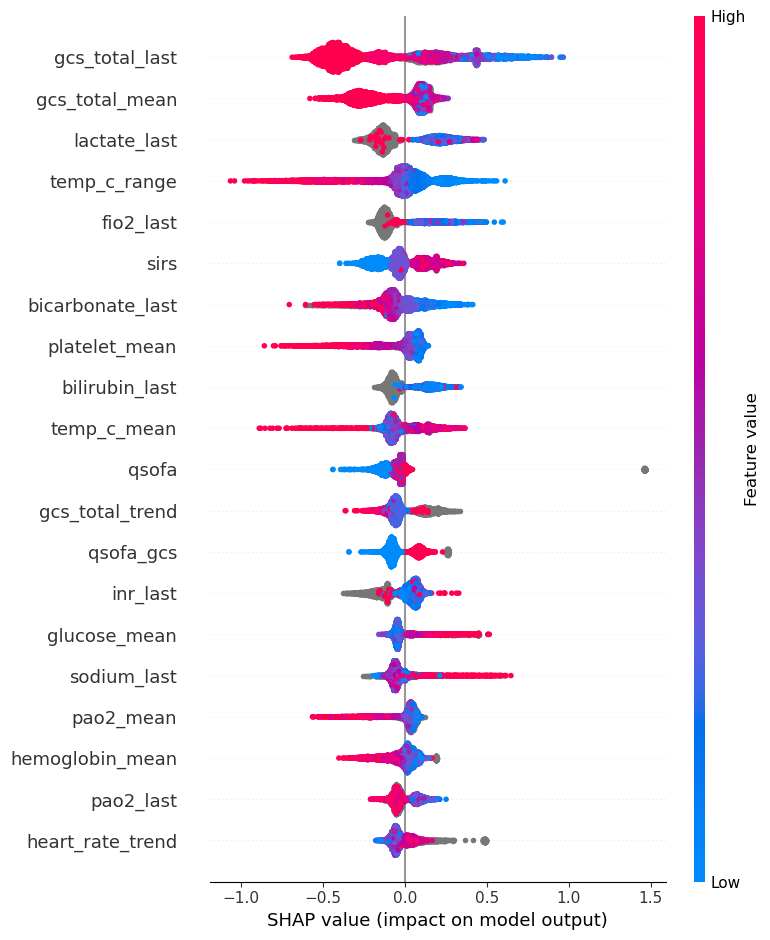

[10:52:56] Guardada: ../experiments/xgboost/shap_beeswarm_6h.png


In [8]:
log("Calculando SHAP values (6h, test set) ...")

explainer   = shap.TreeExplainer(model_6h)
shap_values = explainer.shap_values(X_te6)

mean_abs  = np.abs(shap_values).mean(axis=0)
top_idx   = np.argsort(mean_abs)[::-1][:20]
top_feats = [FEATURE_COLS[i] for i in top_idx]

print("Top 20 features (SHAP |mean|):")
for i, (feat, val) in enumerate(zip(top_feats, mean_abs[top_idx])):
    bar = '█' * int(val / mean_abs[top_idx[0]] * 30)
    print(f"  {i+1:>2}. {feat:<32} {val:.4f}  {bar}")

# summary_plot no acepta ax= en versiones antiguas de shap
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values[:, top_idx], X_te6[top_feats], show=False)
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_beeswarm_6h.png", dpi=150, bbox_inches="tight")
plt.show()
log(f"Guardada: {OUT_DIR / 'shap_beeswarm_6h.png'}")

## PASO 8 — Guardar modelos y métricas

In [9]:
model_6h.save_model(OUT_DIR / "xgboost_6h.json")
model_12h.save_model(OUT_DIR / "xgboost_12h.json")

results = {
    "6h":  {"val": r6_val,  "test": r6_test},
    "12h": {"val": r12_val, "test": r12_test},
    "n_features": len(FEATURE_COLS),
    "metricas_calibracion": NOTA_METRICAS,
}
with open(OUT_DIR / "results.json", "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))
log("Completado — modelos en experiments/xgboost/")

{
  "6h": {
    "val": {
      "auroc": 0.8197,
      "auprc": 0.4626,
      "sens_at_spec90": 0.5379,
      "brier": 0.0599,
      "ece": 0.009,
      "brier_sin_calibrar": 0.1161,
      "ece_sin_calibrar": 0.203,
      "platt_a": 1.104634,
      "platt_b": -1.824772
    },
    "test": {
      "auroc": 0.867,
      "auprc": 0.5609,
      "sens_at_spec90": 0.6275,
      "brier": 0.054,
      "ece": 0.0097,
      "brier_sin_calibrar": 0.1075,
      "ece_sin_calibrar": 0.2006,
      "platt_a": 1.104634,
      "platt_b": -1.824772
    }
  },
  "12h": {
    "val": {
      "auroc": 0.7878,
      "auprc": 0.4365,
      "sens_at_spec90": 0.4943,
      "brier": 0.0626,
      "ece": 0.0102,
      "brier_sin_calibrar": 0.1137,
      "ece_sin_calibrar": 0.1932,
      "platt_a": 0.992442,
      "platt_b": -1.74978
    },
    "test": {
      "auroc": 0.851,
      "auprc": 0.5276,
      "sens_at_spec90": 0.5905,
      "brier": 0.0578,
      "ece": 0.0095,
      "brier_sin_calibrar": 0.1085,
      "e